# ML Project RBK IT School

**Subject area:** Detection of fraudulent transactions in a banking antifraud system.

**Selected dataset:** <a href='https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets'>Financial Transactions Dataset: Analytics</a>

**Dataset with photos:** <a href='https://www.kaggle.com/datasets/vasukipatel/face-recognition-dataset'>Face Recognition Dataset</a>


**Dataset Description:** This dataset contains tables with over 13 million transactions, over 6K cards, and over 2K users, a CSV file with the `is_fraud` target for transactions, and a CSV file with the merchant category code (mcc_description). In total, it contains 41 features. The data includes numerical (transaction amount, credit limit, total debt, annual income), contextual (transaction type, date, geolocation), and demographic (age, gender) features. This set provides many opportunities for feature engineering and identifying hidden patterns.

**Goal:** Build a three-stage system for detecting fraudulent transactions (Classification with XGBoost -> Anomaly Detection with Isolation Forest -> Identity Verification with MobileNetV2)

**Practical tasks:** <br>
- **Basic Scoring (Classical Machine Learning):**
Solve the binary classification problem (predicting classes 0 - legitimate, 1 - fraud) using ensemble methods XGBoost, Random Forest, and compare them with the baseline Logistic Regression algorithm.
- **Anomaly Detection (Unsupervised Learning):**
Solve the problem of finding hidden anomalies using the Isolation Forest algorithm.
- **Biometric Verification (Deep Learning / CNN):**
Develop an identity verification system based on the MobileNetV2 architecture. The neural network solves the image classification problem to verify the true cardholder in case of risk detection by the Isolation Forest algorithm or a high probability of fraud based on the prediction of the classification model.

In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
from sklearn.model_selection import RandomizedSearchCV
import shap
from sklearn.ensemble import IsolationForest
import os
import shutil
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# Block 1: Dataset loading, EDA & Basic Preprocessing

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset Loading

In [4]:
df_transactions = pd.read_csv('/content/drive/MyDrive/Проект RBK/Financial Transactions Dataset: Analytics/transactions_data.csv')
df_cards = pd.read_csv('/content/drive/MyDrive/Проект RBK/Financial Transactions Dataset: Analytics/cards_data.csv')
df_users = pd.read_csv('/content/drive/MyDrive/Проект RBK/Financial Transactions Dataset: Analytics/users_data.csv')

In [5]:
df_transactions.shape

(13305915, 12)

In [6]:
df_cards.shape

(6146, 13)

In [7]:
df_users.shape

(2000, 14)

In [8]:
df_transactions.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


In [9]:
df_cards.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [10]:
df_users.head()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


In [11]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          object 
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             float64
 10  mcc             int64  
 11  errors          object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.2+ GB


In [12]:
df_cards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB


In [13]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   object 
 6   address            2000 non-null   object 
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   object 
 10  yearly_income      2000 non-null   object 
 11  total_debt         2000 non-null   object 
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 218.9+ KB


## Creating customers and transactions views

The dataset has too many scattered data across files and tables. I need to merge tables and JSON files to get a minimum number of views without losing data. Therefore, I will merge mcc_codes.json and train_fraud_labels.json with the transactions table, changing data types along the way to match the table. This will create the transactions view. I will also merge the cards and users tables to create the customers view.

In [14]:
with open('/content/drive/MyDrive/Проект RBK/Financial Transactions Dataset: Analytics/mcc_codes.json', 'r') as file:
    mcc_json = json.load(file)

df_mcc = pd.DataFrame(list(mcc_json.items()), columns=['mcc', 'mcc_description'])
df_mcc['mcc'] = df_mcc['mcc'].astype(df_transactions['mcc'].dtype)

with open('/content/drive/MyDrive/Проект RBK/Financial Transactions Dataset: Analytics/train_fraud_labels.json', 'r') as file:
    fraud_json = json.load(file)

fraud_ids = list(fraud_json['target'].keys())
fraud_values = list(fraud_json['target'].values())
df_fraud_labels = pd.DataFrame({'id': fraud_ids, 'is_fraud': fraud_values})
df_fraud_labels['id'] = df_fraud_labels['id'].astype(df_transactions['id'].dtype)

In [15]:
df_mcc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   mcc              109 non-null    int64 
 1   mcc_description  109 non-null    object
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


In [16]:
df_fraud_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 2 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   id        int64 
 1   is_fraud  object
dtypes: int64(1), object(1)
memory usage: 136.0+ MB


In [17]:
vitrina_transactions = df_transactions.merge(df_mcc, on='mcc', how='left')
vitrina_transactions = vitrina_transactions.merge(df_fraud_labels, on='id', how='left')

vitrina_customers = df_users.merge(df_cards, left_on='id', right_on='client_id', how='left')

In [18]:
vitrina_transactions.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,mcc_description,is_fraud
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN,Miscellaneous Food Stores,No
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN,Department Stores,No
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,Money Transfer,No
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN,Money Transfer,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN,Drinking Places (Alcoholic Beverages),No


In [19]:
vitrina_customers.head()

,id_x,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,...,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,...,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,...,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,...,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,...,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [20]:
del df_transactions, df_users, df_cards
gc.collect()

0

## Initial EDA

### Transactions

In [21]:
vitrina_transactions.shape

(13305915, 14)

In [22]:
vitrina_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 14 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id               int64  
 1   date             object 
 2   client_id        int64  
 3   card_id          int64  
 4   amount           object 
 5   use_chip         object 
 6   merchant_id      int64  
 7   merchant_city    object 
 8   merchant_state   object 
 9   zip              float64
 10  mcc              int64  
 11  errors           object 
 12  mcc_description  object 
 13  is_fraud         object 
dtypes: float64(1), int64(5), object(8)
memory usage: 1.4+ GB


In [23]:
vitrina_transactions.isnull().sum()

,0
id,0
date,0
client_id,0
card_id,0
amount,0
use_chip,0
merchant_id,0
merchant_city,0
merchant_state,1563700
zip,1652706


In [24]:
vitrina_transactions[(vitrina_transactions['zip'].isnull()) & (vitrina_transactions['merchant_state'].isnull())].head(10)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,mcc_description,is_fraud
7,7475335,2010-01-01 00:14:00,1684,2140,$26.46,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees,No
8,7475336,2010-01-01 00:21:00,335,5131,$261.58,Online Transaction,50292,ONLINE,NaN,NaN,7801,NaN,"Athletic Fields, Commercial Sports",NaN
18,7475346,2010-01-01 00:34:00,394,4717,$26.04,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees,No
24,7475353,2010-01-01 00:43:00,301,3742,$10.17,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees,No
26,7475356,2010-01-01 00:45:00,566,3439,$16.86,Online Transaction,16798,ONLINE,NaN,NaN,4121,NaN,Taxicabs and Limousines,NaN
29,7475359,2010-01-01 00:48:00,1127,3869,$22.57,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees,No
35,7475365,2010-01-01 01:01:00,820,127,$270.22,Online Transaction,73186,ONLINE,NaN,NaN,4814,NaN,Telecommunication Services,No
37,7475367,2010-01-01 01:06:00,1758,4686,$87.09,Online Transaction,17976,ONLINE,NaN,NaN,4900,NaN,"Utilities - Electric, Gas, Water, Sanitary",No
41,7475372,2010-01-01 01:11:00,566,5577,$14.66,Online Transaction,16798,ONLINE,NaN,NaN,4121,NaN,Taxicabs and Limousines,No
43,7475374,2010-01-01 01:13:00,1684,94,$12.67,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees,NaN


We can see that all cases of missing zip and merchant_state indicate an online transaction.

In [25]:
vitrina_transactions[(vitrina_transactions['zip'].isnull()) & (vitrina_transactions['merchant_city'] != 'ONLINE')].head(10)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,mcc_description,is_fraud
581,7476010,2010-01-01 07:53:00,1579,3830,$6.51,Swipe Transaction,22204,Puerto Vallarta,Mexico,NaN,5541,NaN,Service Stations,No
1026,7476549,2010-01-01 10:03:00,363,5555,$8.16,Swipe Transaction,93391,Vatican City,Vatican City,NaN,5812,NaN,Eating Places and Restaurants,No
1148,7476704,2010-01-01 10:37:00,363,5555,$11.66,Swipe Transaction,93391,Vatican City,Vatican City,NaN,5812,NaN,Eating Places and Restaurants,No
1706,7477375,2010-01-01 12:50:00,1266,2478,$9.77,Swipe Transaction,22204,Guadalajara,Mexico,NaN,5541,NaN,Service Stations,No
1836,7477534,2010-01-01 13:19:00,1266,2478,$11.32,Swipe Transaction,75804,Guadalajara,Mexico,NaN,5411,NaN,"Grocery Stores, Supermarkets",NaN
2404,7478204,2010-01-01 16:07:00,363,5364,$10.40,Swipe Transaction,13067,Vatican City,Vatican City,NaN,5411,NaN,"Grocery Stores, Supermarkets",NaN
3364,7479335,2010-01-01 22:35:00,738,204,$57.80,Swipe Transaction,246,Santo Domingo,Dominican Republic,NaN,5812,NaN,Eating Places and Restaurants,No
3920,7479985,2010-01-02 07:43:00,1579,11,$7.38,Swipe Transaction,7886,Puerto Vallarta,Mexico,NaN,5812,NaN,Eating Places and Restaurants,NaN
4483,7480670,2010-01-02 10:51:00,363,5555,$11.94,Swipe Transaction,13067,Vatican City,Vatican City,NaN,5411,NaN,"Grocery Stores, Supermarkets",NaN
5378,7481731,2010-01-02 15:02:00,738,5774,$119.29,Swipe Transaction,33820,Santo Domingo,Dominican Republic,NaN,5912,NaN,Drug Stores and Pharmacies,NaN


In [26]:
vitrina_transactions[(vitrina_transactions['merchant_state'].isnull()) & (vitrina_transactions['merchant_city'] != 'ONLINE')].shape[0]

0

In [27]:
vitrina_transactions[(vitrina_transactions['zip'].isnull()) & (vitrina_transactions['merchant_city'] != 'ONLINE')].shape[0]

89006

89006 is exactly the difference between missing values in zip and merchant_state, which proves that if a transaction was not conducted online and the zip is missing, it means the transaction was 100% conducted outside the USA (this dataset contains user data from the USA).

#### Conclusion about missing values
1. The absence of both merchant_state and zip indicates an online transaction. I will replace missing merchant_state with 'ONLINE'.
2. The absence of only zip indicates a transaction outside the USA. I will replace missing zip with -1.
3. Missing values in 'errors' represent successful transactions without errors. I will replace them with the category 'No Error'.
4. Missing values in 'is_fraud' are explained by the fact that this dataset was taken from Kaggle and most likely NaN was deliberately set for the target in the test set to prevent cheating in competitions. I will remove these rows, as the test data must be labeled for model evaluation.

In [28]:
vitrina_transactions.duplicated().sum()

np.int64(0)

### Customers

In [29]:
vitrina_customers.shape

(6146, 27)

In [30]:
vitrina_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_x                   6146 non-null   int64  
 1   current_age            6146 non-null   int64  
 2   retirement_age         6146 non-null   int64  
 3   birth_year             6146 non-null   int64  
 4   birth_month            6146 non-null   int64  
 5   gender                 6146 non-null   object 
 6   address                6146 non-null   object 
 7   latitude               6146 non-null   float64
 8   longitude              6146 non-null   float64
 9   per_capita_income      6146 non-null   object 
 10  yearly_income          6146 non-null   object 
 11  total_debt             6146 non-null   object 
 12  credit_score           6146 non-null   int64  
 13  num_credit_cards       6146 non-null   int64  
 14  id_y                   6146 non-null   int64  
 15  clie

In [31]:
vitrina_customers[['id_x','client_id','id_y']].head()

,id_x,client_id,id_y
0,825,825,4524
1,825,825,2731
2,825,825,3701
3,825,825,42
4,825,825,4659


In [32]:
(vitrina_customers['id_x'] != vitrina_customers['client_id']).sum()

np.int64(0)

Since the id_x and client_id columns duplicate each other, one can be removed. The id_y column is card_id.

In [33]:
vitrina_customers[['per_capita_income', 'yearly_income', 'total_debt', 'credit_limit']].head()

,per_capita_income,yearly_income,total_debt,credit_limit
0,$29278,$59696,$127613,$24295
1,$29278,$59696,$127613,$21968
2,$29278,$59696,$127613,$46414
3,$29278,$59696,$127613,$12400
4,$29278,$59696,$127613,$28


In [34]:
vitrina_customers.isnull().sum()

,0
id_x,0
current_age,0
retirement_age,0
birth_year,0
birth_month,0
gender,0
address,0
latitude,0
longitude,0
per_capita_income,0


In [35]:
vitrina_customers.duplicated().sum()

np.int64(0)

## Basic Preprocessing

### Transactions

In [36]:
vitrina_transactions['amount'] = vitrina_transactions['amount'].astype(str).str.replace('$', '', regex=False).str.strip().astype(float)

vitrina_transactions["date"] = pd.to_datetime(vitrina_transactions["date"])

vitrina_transactions = vitrina_transactions.dropna(subset=['is_fraud']).copy()
vitrina_transactions['is_fraud'] = vitrina_transactions['is_fraud'].map({'Yes': 1, 'No': 0}).astype(np.int8)

vitrina_transactions['errors'] = vitrina_transactions['errors'].fillna('No Error')

vitrina_transactions['merchant_state'] = vitrina_transactions['merchant_state'].fillna('ONLINE')

vitrina_transactions['zip'] = vitrina_transactions['zip'].fillna(-1)

vitrina_transactions = vitrina_transactions.rename(columns={'id': 'transaction_id'})

In [37]:
vitrina_transactions.isnull().sum()

,0
transaction_id,0
date,0
client_id,0
card_id,0
amount,0
use_chip,0
merchant_id,0
merchant_city,0
merchant_state,0
zip,0


In [38]:
vitrina_transactions.head()

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,mcc_description,is_fraud
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,No Error,Miscellaneous Food Stores,0
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,No Error,Department Stores,0
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,No Error,Money Transfer,0
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,No Error,Drinking Places (Alcoholic Beverages),0
5,7475333,2010-01-01 00:07:00,1807,165,4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,No Error,Book Stores,0


In [39]:
vitrina_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8914963 entries, 0 to 13305912
Data columns (total 14 columns):
 #   Column           Dtype         
---  ------           -----         
 0   transaction_id   int64         
 1   date             datetime64[ns]
 2   client_id        int64         
 3   card_id          int64         
 4   amount           float64       
 5   use_chip         object        
 6   merchant_id      int64         
 7   merchant_city    object        
 8   merchant_state   object        
 9   zip              float64       
 10  mcc              int64         
 11  errors           object        
 12  mcc_description  object        
 13  is_fraud         int8          
dtypes: datetime64[ns](1), float64(2), int64(5), int8(1), object(5)
memory usage: 960.7+ MB


### Customers

In [40]:
vitrina_customers = vitrina_customers.drop(columns=['client_id'])
vitrina_customers = vitrina_customers.rename(columns={'id_x': 'client_id', 'id_y': 'card_id'})

finance_cols = ['per_capita_income', 'yearly_income', 'total_debt', 'credit_limit']

for col in finance_cols:
  vitrina_customers[col] = vitrina_customers[col].astype(str).str.replace('$', '', regex=False).str.strip().astype(float)

vitrina_customers['acct_open_date'] = pd.to_datetime(vitrina_customers['acct_open_date'], format='%m/%Y')
vitrina_customers['expires'] = pd.to_datetime(vitrina_customers['expires'], format='%m/%Y') + pd.offsets.MonthEnd(0)

In [41]:
vitrina_customers[['per_capita_income', 'yearly_income', 'total_debt', 'credit_limit', 'acct_open_date', 'expires']].head()

,per_capita_income,yearly_income,total_debt,credit_limit,acct_open_date,expires
0,29278.0,59696.0,127613.0,24295.0,2002-09-01,2022-12-31
1,29278.0,59696.0,127613.0,21968.0,2014-04-01,2020-12-31
2,29278.0,59696.0,127613.0,46414.0,2003-07-01,2024-02-29
3,29278.0,59696.0,127613.0,12400.0,2003-01-01,2024-08-31
4,29278.0,59696.0,127613.0,28.0,2008-09-01,2009-03-31


In [42]:
vitrina_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   client_id              6146 non-null   int64         
 1   current_age            6146 non-null   int64         
 2   retirement_age         6146 non-null   int64         
 3   birth_year             6146 non-null   int64         
 4   birth_month            6146 non-null   int64         
 5   gender                 6146 non-null   object        
 6   address                6146 non-null   object        
 7   latitude               6146 non-null   float64       
 8   longitude              6146 non-null   float64       
 9   per_capita_income      6146 non-null   float64       
 10  yearly_income          6146 non-null   float64       
 11  total_debt             6146 non-null   float64       
 12  credit_score           6146 non-null   int64         
 13  num

In [43]:
vitrina_transactions.to_parquet('vitrina_transactions.parquet', index=False)
vitrina_customers.to_parquet('vitrina_customers.parquet', index=False)

# Block 2: Visual EDA
Restarting Colab session to clear RAM here.

In [2]:
vitrina_transactions = pd.read_parquet('vitrina_transactions.parquet')
vitrina_customers = pd.read_parquet('vitrina_customers.parquet')

## Статистика после предобработки

In [3]:
vitrina_transactions.describe()

,transaction_id,date,client_id,card_id,amount,merchant_id,zip,mcc,is_fraud
count,8.914963e+06,8914963,8.914963e+06,8.914963e+06,8.914963e+06,8.914963e+06,8.914963e+06,8.914963e+06,8.914963e+06
mean,1.558473e+07,2015-01-06 10:38:50.359852288,1.026637e+03,3.474887e+03,4.294939e+01,4.772566e+04,4.495262e+04,5.565097e+03,1.495463e-03
min,7.475327e+06,2010-01-01 00:01:00,0.000000e+00,0.000000e+00,-5.000000e+02,1.000000e+00,-1.000000e+00,1.711000e+03,0.000000e+00
25%,1.150786e+07,2012-08-09 10:34:00,5.190000e+02,2.413000e+03,8.930000e+00,2.588700e+04,1.507800e+04,5.300000e+03,0.000000e+00
50%,1.557140e+07,2015-01-22 14:06:00,1.070000e+03,3.584000e+03,2.899000e+01,4.592600e+04,4.110200e+04,5.499000e+03,0.000000e+00
75%,1.965387e+07,2017-06-13 19:22:30,1.530000e+03,4.899000e+03,6.368000e+01,6.757000e+04,7.550100e+04,5.812000e+03,0.000000e+00
max,2.376187e+07,2019-10-31 23:57:00,1.998000e+03,6.138000e+03,6.613440e+03,1.003420e+05,9.992800e+04,9.402000e+03,1.000000e+00
std,4.703991e+06,NaN,5.816755e+02,1.674427e+03,8.152652e+01,2.581623e+04,3.230915e+04,8.755078e+02,3.864230e-02


In [4]:
vitrina_transactions.describe(include="object")

,use_chip,merchant_city,merchant_state,errors,mcc_description
count,8914963,8914963,8914963,8914963,8914963
unique,3,12173,200,23,108
top,Swipe Transaction,ONLINE,ONLINE,No Error,"Grocery Stores, Supermarkets"
freq,4668212,1047865,1047865,8773196,1066833


In [5]:
vitrina_customers.describe()

,client_id,current_age,retirement_age,birth_year,birth_month,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_id,card_number,expires,cvv,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed
count,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6.146000e+03,6146,6146.000000,6146.000000,6146.000000,6146,6146.000000
mean,994.939636,50.139766,66.544582,1969.050439,6.467296,37.314732,-91.801489,23254.139440,45313.309795,57644.721445,718.252522,3.945005,3072.500000,4.820426e+15,2020-11-06 16:22:38.932638976,506.220794,1.503091,14347.493980,2011-01-15 12:55:31.727953152,2013.436707
min,0.000000,18.000000,50.000000,1918.000000,1.000000,20.880000,-159.410000,0.000000,1.000000,0.000000,480.000000,1.000000,0.000000,3.001055e+14,1997-07-31 00:00:00,0.000000,1.000000,0.000000,1991-01-01 00:00:00,2002.000000
25%,492.250000,35.000000,65.000000,1957.000000,3.000000,33.820000,-97.510000,16844.000000,32295.000000,16803.000000,687.000000,3.000000,1536.250000,4.486365e+15,2020-02-29 00:00:00,257.000000,1.000000,7042.750000,2006-10-01 00:00:00,2010.000000
50%,992.000000,50.000000,67.000000,1970.000000,7.000000,38.160000,-86.795000,20646.500000,40251.000000,51529.500000,717.500000,4.000000,3072.500000,5.108957e+15,2021-09-30 00:00:00,516.500000,1.000000,12592.500000,2010-02-15 00:00:00,2013.000000
75%,1495.000000,63.000000,69.000000,1984.000000,10.000000,41.130000,-80.130000,26369.000000,52531.500000,84494.500000,760.000000,5.000000,4608.750000,5.585237e+15,2023-05-31 00:00:00,756.000000,2.000000,19156.500000,2016-05-01 00:00:00,2017.000000
max,1999.000000,101.000000,79.000000,2002.000000,12.000000,61.200000,-68.670000,163145.000000,307018.000000,516263.000000,850.000000,9.000000,6145.000000,6.997197e+15,2024-12-31 00:00:00,999.000000,3.000000,151223.000000,2020-02-01 00:00:00,2020.000000
std,578.614626,18.975960,3.455030,18.969825,3.547927,5.148899,16.454556,11512.323216,23314.172216,51633.885249,63.227622,1.668031,1774.341709,1.328582e+15,NaN,289.431123,0.519191,12014.463884,NaN,4.270699


In [6]:
vitrina_customers.describe(include="object")

,gender,address,card_brand,card_type,has_chip,card_on_dark_web
count,6146,6146,6146,6146,6146,6146
unique,2,1999,4,3,2,1
top,Female,31 Hillside Lane,Mastercard,Debit,YES,No
freq,3139,9,3209,3511,5500,6146


The `card_on_dark_web` column has only 1 unique value, so it can be deleted.

In [7]:
vitrina_customers = vitrina_customers.drop(columns=['card_on_dark_web'])

## Creating a single dataframe with the most important features

In [8]:
customer_features = [
    'card_id',
    'client_id',
    'current_age',
    'gender',
    'latitude',
    'longitude',
    'yearly_income',
    'total_debt',
    'credit_score',
    'num_credit_cards',
    'card_brand',
    'card_type',
    'expires',
    'has_chip',
    'num_cards_issued',
    'credit_limit',
    'acct_open_date',
    'year_pin_last_changed'
]

transaction_features = [
    'transaction_id',
    'card_id',
    'date',
    'amount',
    'use_chip',
    'mcc',
    'mcc_description',
    'errors',
    'merchant_state',
    'zip',
    'is_fraud'
]

df_full = pd.merge(vitrina_transactions[transaction_features], vitrina_customers[customer_features], on='card_id', how='inner')
df_full['hour'] = df_full['date'].dt.hour

In [9]:
del vitrina_transactions, vitrina_customers
gc.collect()

31

In [10]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 29 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   transaction_id         int64         
 1   card_id                int64         
 2   date                   datetime64[ns]
 3   amount                 float64       
 4   use_chip               object        
 5   mcc                    int64         
 6   mcc_description        object        
 7   errors                 object        
 8   merchant_state         object        
 9   zip                    float64       
 10  is_fraud               int8          
 11  client_id              int64         
 12  current_age            int64         
 13  gender                 object        
 14  latitude               float64       
 15  longitude              float64       
 16  yearly_income          float64       
 17  total_debt             float64       
 18  credit_score          

## Plots

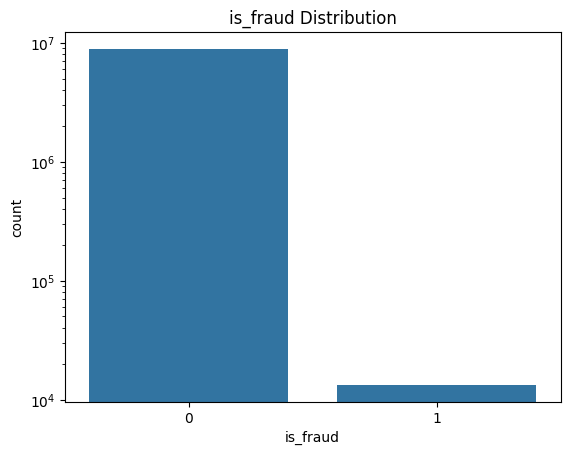

is_fraud
0    99.850454
1     0.149546
Name: proportion, dtype: float64


In [11]:
sns.countplot(df_full, x='is_fraud')
plt.yscale('log')
plt.title('is_fraud Distribution')
plt.show()
print(df_full['is_fraud'].value_counts(normalize=True) * 100)

There is a class imbalance in the target, as the percentage of fraud is very small compared to legitimate transactions, which means Accuracy will be useless in this case. For example, a model might always predict class 0 (legitimate transaction) and get very high Accuracy. We will need to use Recall, Precision, F1-score, PR-AUC. For anti-fraud systems, it is much more important to detect as many fraudulent operations as possible, so the main metric will be Recall. Additionally, I will use PR-AUC, which better reflects model quality on imbalanced data and shows the trade-off between Precision and Recall.

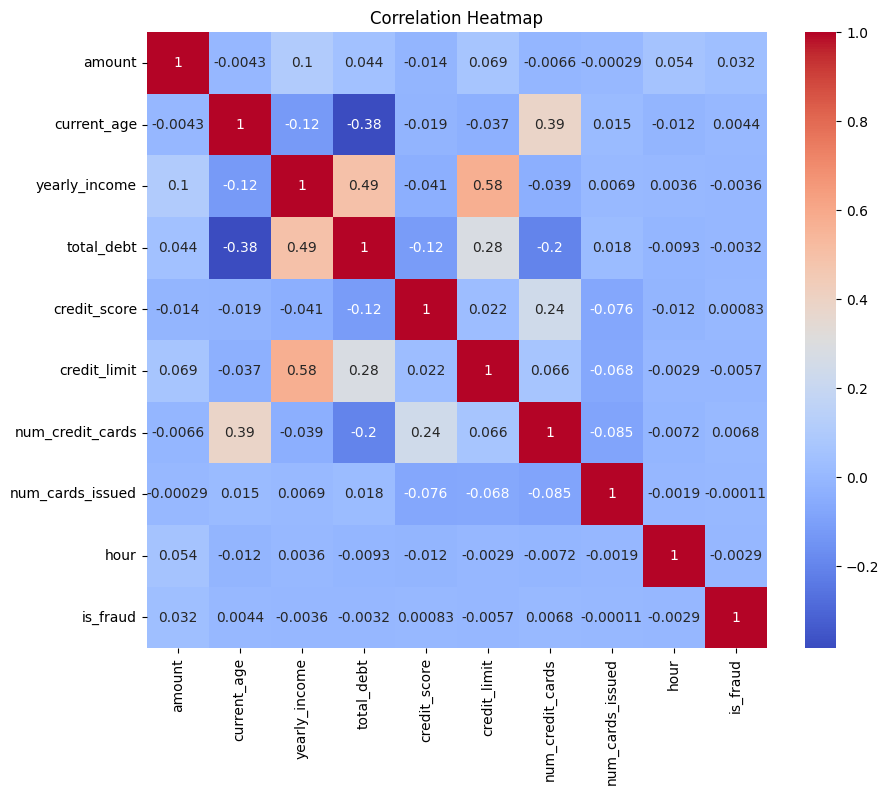

In [12]:
num_cols = [
    'amount',
    'current_age',
    'yearly_income',
    'total_debt',
    'credit_score',
    'credit_limit',
    'num_credit_cards',
    'num_cards_issued',
    'hour',
    'is_fraud'
]

corr = df_full[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Numerical features do not have a high correlation with the `is_fraud` target (the maximum correlation with amount is 0.032), which means that to detect fraud, more complex nonlinear dependencies need to be considered. This is a reason to use ensemble tree methods (XGBoost, Random Forest), which can build complex logical chains. In addition, we observe a positive correlation between credit_limit and yearly_income, current_age and num_credit_cards, total_debt and yearly_income. There is also a negative correlation between total_debt and num_credit_cards, total_debt and current_age.

### Sample for Visual EDA
Since the dataset is too large and has class imbalance, I will build further graphs on a sample where the percentage of fraud is artificially increased compared to legitimate transactions for visibility on the graphs.

In [13]:
df_sample_eda = pd.concat([df_full[df_full['is_fraud'] == 1], df_full[df_full['is_fraud'] == 0].sample(50000, random_state=42)]).reset_index(drop=True)

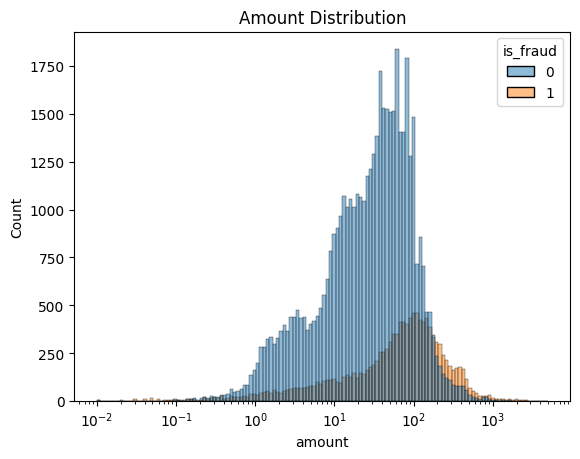

In [14]:
sns.histplot(data=df_sample_eda[df_sample_eda['amount'] > 0], x='amount', hue='is_fraud', log_scale=True, common_norm=False)
plt.title('Amount Distribution')
plt.show()

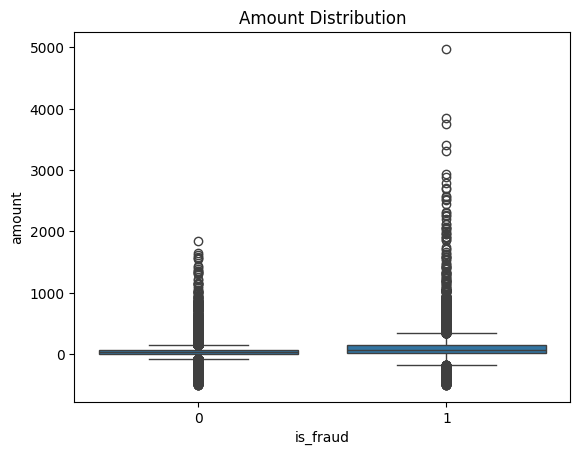

In [15]:
sns.boxplot(data=df_sample_eda, x='is_fraud', y='amount')
plt.title('Amount Distribution')
plt.show()

In [16]:
df_sample_eda.groupby('is_fraud')['amount'].skew()

,amount
is_fraud,
0,4.100234
1,5.746335


Fraudulent transaction outliers reach up to \$5000, while legitimate ones reach up to \$2000. Most legitimate transactions are between \$10 and \$100, and fraudulent ones are approximately between \$50 and \$400. The distribution of amounts is right-skewed. Fraudulent transactions have a larger number of large amounts, which shows a long tail of outliers. This means that 'amount' will be a good feature for anomaly detection. The presence of negative amounts can be explained by refunds and canceled payments.

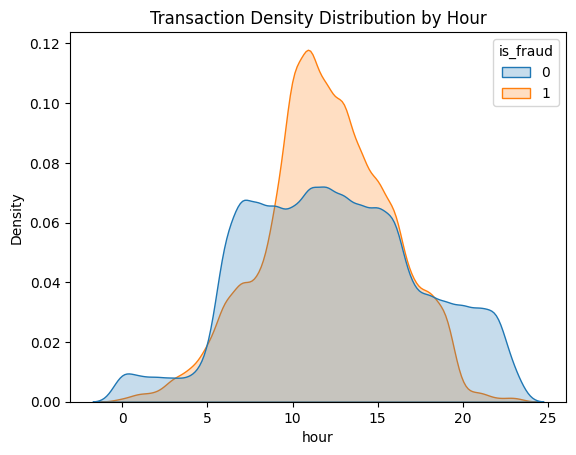

In [17]:
sns.kdeplot(data=df_sample_eda, x='hour', hue='is_fraud', fill=True, common_norm=False)
plt.title('Transaction Density Distribution by Hour')
plt.show()

Legitimate transactions are smoothly distributed throughout the day from morning to evening (6:00 - 16:00). Fraudulent transactions sharply increase early in the morning at 5:00 and peak around 10:00-13:00.

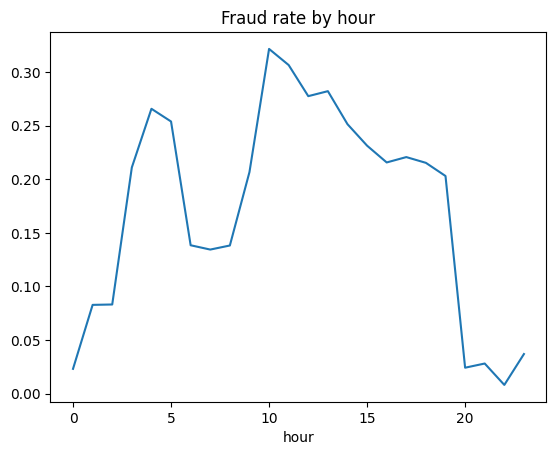

In [18]:
fraud_rate_hour = df_sample_eda.groupby('hour')['is_fraud'].mean()
fraud_rate_hour.plot()
plt.title('Fraud rate by hour')
plt.show()

The risk of a fraudulent attack sharply increases to 27% late at night between 3:00-5:00, and also up to 32% during the day between 10:00-13:00.

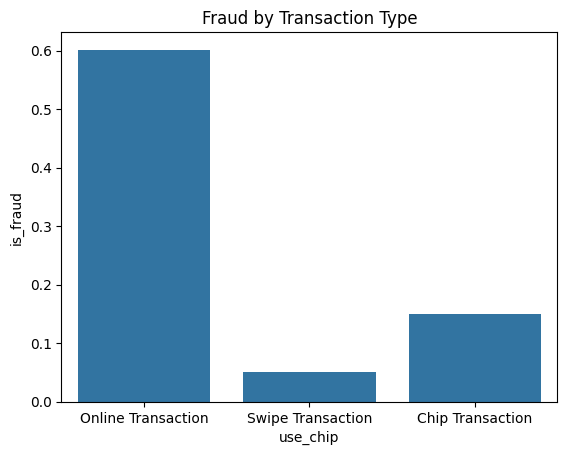

In [19]:
sns.barplot(data=df_sample_eda, x='use_chip', y='is_fraud', errorbar=None)
plt.title('Fraud by Transaction Type')
plt.show()

Online Transaction type (e-commerce, website purchases) carries the maximum risk of fraud. The percentage of fraud by this method reaches 60%. Physical card operations are much better protected. Swipe Transaction (magnetic stripe swipe) and Chip Transaction (chip payment) have minimal fraud levels. This feature will need to be encoded, as it is important for the model.

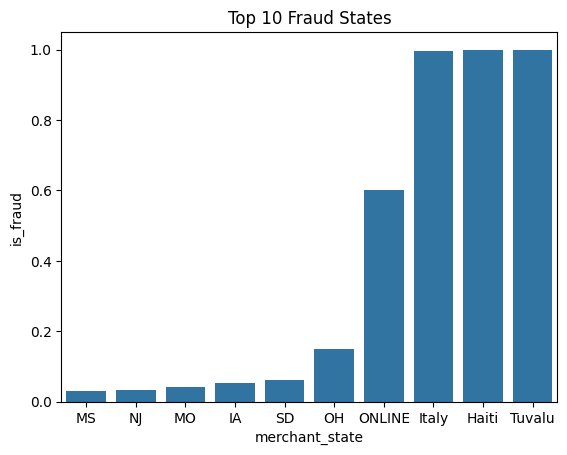

In [20]:
top10 = df_sample_eda.groupby('merchant_state')['is_fraud'].mean().sort_values().tail(10).reset_index()
sns.barplot(data=top10, x='merchant_state', y='is_fraud')
plt.title('Top 10 Fraud States')
plt.show()

This graph shows the locations of stores (physical or online sites) where fraudsters attempted to pay with a stolen card. The leaders among them are Tuvalu, Haiti, Italy with 100% fraud, and ONLINE transactions with 60% fraud. This only includes international and online transactions.

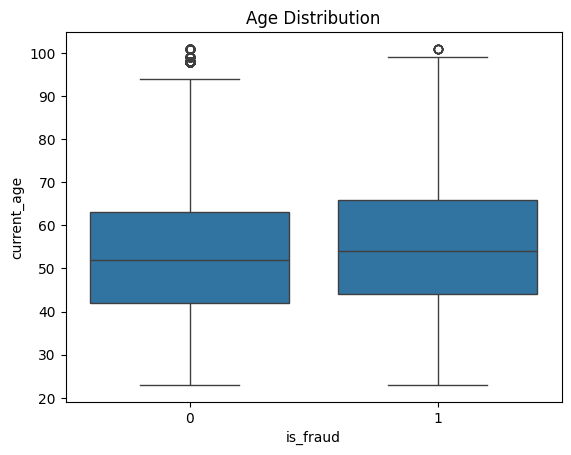

In [21]:
sns.boxplot(data=df_sample_eda, x='is_fraud', y='current_age')
plt.title('Age Distribution')
plt.show()

Judging by the graph, age is not a key factor for fraud, as the difference between the medians and boxes of legitimate and fraudulent transactions is approximately at the same level. Most legitimate transactions are concentrated between 41 and 61 years old. For fraud, they are slightly shifted upwards from 43 to 65 years old. For both classes, there are outliers up to 100 years. Fraudsters more often attack people of mature and elderly age, as they are less aware of fraud methods. In our case, age is not such an indicative factor for determining fraud. However, the correlation matrix shows that age has more connections with total_debt, num_credit_cards, and yearly_income. So it can be useful in conjunction with other features.

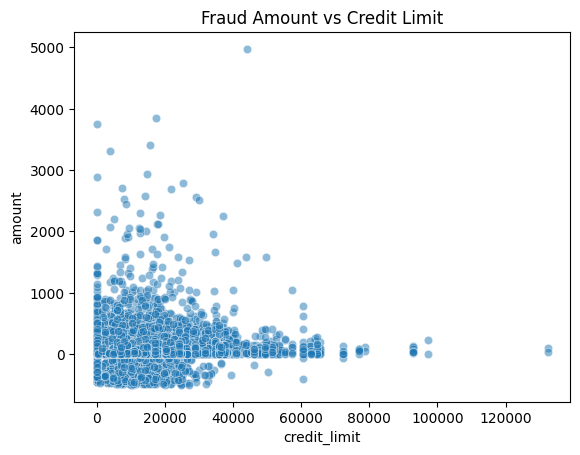

In [22]:
sns.scatterplot(data=df_sample_eda[df_sample_eda['is_fraud']==1], x='credit_limit', y='amount', alpha=0.5)
plt.title('Fraud Amount vs Credit Limit')
plt.show()

Most fraudulent operations are concentrated around relatively small credit limits. This means that fraudsters usually attack the cards of ordinary people. Primarily, they steal amounts up to $1000, but amounts can reach up to $5000. However, the higher the card limit, the lower the amounts tend to be. Perhaps on expensive cards, the security system works more strictly for large transactions. Amounts below zero represent transaction reversals (chargebacks).

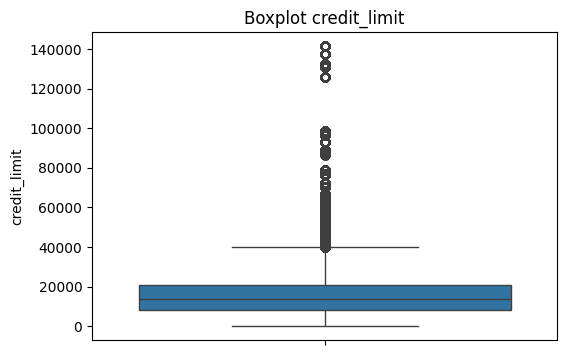

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_full["credit_limit"])
plt.title("Boxplot credit_limit")
plt.show()

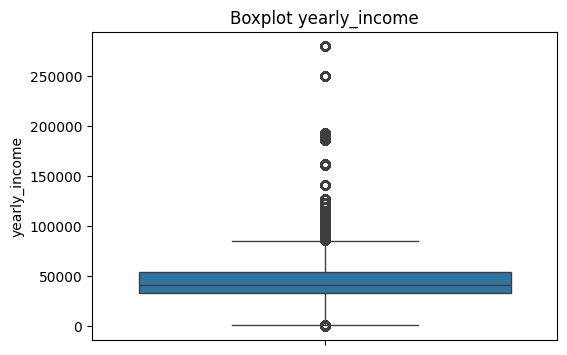

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_full["yearly_income"])
plt.title("Boxplot yearly_income")
plt.show()

Outliers are present in numerical features. However, these are real values (large purchases, high income, or large credit limit), not measurement errors. Since Random Forest and XGBoost are robust to outliers, removing them is not expedient. Additionally, large transaction amounts can be an important indicator of fraud.

In [25]:
del corr, df_sample_eda, top10
gc.collect()

37942

## Sample for further feature engineering, encoding, and model training

It will be impossible to train models on the full dataset due to its large volume and Colab's memory limitations. Therefore, I will train models on a balanced sample where the percentage of fraud is higher than in the real dataset. For the model to learn nonlinear dependencies better, it needs to see more examples of fraud. The validation set will be stratified to accurately reflect reality.

In [26]:
_, df_sample = train_test_split(df_full, test_size=0.10, stratify=df_full['is_fraud'], random_state=42)

In [27]:
del df_full
gc.collect()

39334

In [28]:
df_sample.to_parquet('df_sample_10.parquet', index=False)

# Block 3: Feature Engineering, Encoding & Modelling
Restarting Colab session to clear RAM here.

## Feature Engineering & Encoding

In [2]:
df_sample = pd.read_parquet('df_sample_10.parquet')

In [3]:
df_sample.shape

(891497, 29)

In [4]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891497 entries, 0 to 891496
Data columns (total 29 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   transaction_id         891497 non-null  int64         
 1   card_id                891497 non-null  int64         
 2   date                   891497 non-null  datetime64[ns]
 3   amount                 891497 non-null  float64       
 4   use_chip               891497 non-null  object        
 5   mcc                    891497 non-null  int64         
 6   mcc_description        891497 non-null  object        
 7   errors                 891497 non-null  object        
 8   merchant_state         891497 non-null  object        
 9   zip                    891497 non-null  float64       
 10  is_fraud               891497 non-null  int8          
 11  client_id              891497 non-null  int64         
 12  current_age            891497 non-null  int6

### Feature Creation

In [5]:
df_sample['day_of_week'] = df_sample['date'].dt.dayofweek
df_sample['month'] = df_sample['date'].dt.month
df_sample['hour_sin'] = np.sin(2 * np.pi * df_sample['hour'] / 24.0)
df_sample['hour_cos'] = np.cos(2 * np.pi * df_sample['hour'] / 24.0)

df_sample['card_age_months'] = (df_sample['date'].dt.year - df_sample['acct_open_date'].dt.year) * 12 + (df_sample['date'].dt.month - df_sample['acct_open_date'].dt.month)
df_sample['months_to_expiry'] = (df_sample['expires'].dt.year - df_sample['date'].dt.year) * 12 + (df_sample['expires'].dt.month - df_sample['date'].dt.month)

df_sample['is_international'] = ((df_sample['zip'] == -1) & (df_sample['merchant_state'] != 'ONLINE')).astype(int)

**day_of_week:** Indicates the day of the week the transaction occurred, which can affect user behavior, as fraudulent activity is often unevenly distributed.

**month:** Indicates the month the transaction occurred, allowing for seasonal financial operations.

**hour_sin** and **hour_cos:** Sine and cosine allow for accounting that 23 hours and 0 hours are close in time.

**card_age_months:** Shows the age of the card at the time of the transaction, which can affect the risk of fraud, for example, if the card is new and large transactions are immediately conducted through it.

**months_to_expiry:** Shows the number of months until the card expires. Cards nearing their expiration date may be used more frequently by fraudsters.

**is_international:** Indicates whether the operation is international. International transactions, as found during EDA, are more often fraudulent.

### Splitting into Train/Test
Done before scaling and encoding to avoid data leakage.

In [6]:
X_full = df_sample.drop(columns=['is_fraud'])
y_full = df_sample['is_fraud']

In [7]:
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X_full, y_full, test_size=0.2, stratify=y_full, random_state=42)

In [8]:
test_passports = X_test[['transaction_id', 'client_id', 'card_id']].copy()

In [9]:
cols_to_drop = ['transaction_id', 'client_id', 'card_id', 'date', 'expires', 'acct_open_date', 'zip', 'mcc']
X_train_raw = X_train_raw.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

These columns need to be removed to avoid overfitting due to noise and the model memorizing the data.

### Balancing Train Set

In [10]:
train_raw = pd.concat([X_train_raw, y_train_raw], axis=1)
fraud_train = train_raw[train_raw['is_fraud'] == 1]
legit_train = train_raw[train_raw['is_fraud'] == 0]

In [11]:
legit_sampled = legit_train.sample(n=len(fraud_train) * 10, random_state=42)

In [12]:
balanced_train = pd.concat([fraud_train, legit_sampled]).sample(frac=1, random_state=42)

In [13]:
X_train = balanced_train.drop(columns=['is_fraud'])
y_train = balanced_train['is_fraud']

### Encoding Categorical Features
Using Target Encoding for a large number of categories and One-Hot Encoding for a small number of categories.

#### Target Encoding

In [14]:
global_mean = y_train.mean()

for col in ['merchant_state', 'mcc_description', 'errors']:
    target_mean = y_train.groupby(X_train[col]).mean()
    X_train[col] = X_train[col].map(target_mean)
    X_test[col] = X_test[col].map(target_mean)

    X_train[col] = X_train[col].fillna(global_mean)
    X_test[col] = X_test[col].fillna(global_mean)

#### One-Hot Encoding

In [15]:
X_train = pd.get_dummies(X_train, columns=['use_chip', 'gender', 'card_brand', 'card_type', 'has_chip'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['use_chip', 'gender', 'card_brand', 'card_type', 'has_chip'],drop_first=True)

In [16]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [17]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11726 entries, 143144 to 336247
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   amount                       11726 non-null  float64
 1   mcc_description              11726 non-null  float64
 2   errors                       11726 non-null  float64
 3   merchant_state               11726 non-null  float64
 4   current_age                  11726 non-null  int64  
 5   latitude                     11726 non-null  float64
 6   longitude                    11726 non-null  float64
 7   yearly_income                11726 non-null  float64
 8   total_debt                   11726 non-null  float64
 9   credit_score                 11726 non-null  int64  
 10  num_credit_cards             11726 non-null  int64  
 11  num_cards_issued             11726 non-null  int64  
 12  credit_limit                 11726 non-null  float64
 13  year_pin_last_c

In [18]:
bool_cols = X_train.select_dtypes(include=['bool']).columns
X_train[bool_cols] = X_train[bool_cols].astype(np.int8)
X_test[bool_cols] = X_test[bool_cols].astype(np.int8)

In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11726 entries, 143144 to 336247
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   amount                       11726 non-null  float64
 1   mcc_description              11726 non-null  float64
 2   errors                       11726 non-null  float64
 3   merchant_state               11726 non-null  float64
 4   current_age                  11726 non-null  int64  
 5   latitude                     11726 non-null  float64
 6   longitude                    11726 non-null  float64
 7   yearly_income                11726 non-null  float64
 8   total_debt                   11726 non-null  float64
 9   credit_score                 11726 non-null  int64  
 10  num_credit_cards             11726 non-null  int64  
 11  num_cards_issued             11726 non-null  int64  
 12  credit_limit                 11726 non-null  float64
 13  year_pin_last_c

### Scaling (for Logistic Regression)

In [20]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
num_cols_to_scale = ['amount', 'current_age', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'num_cards_issued',
                     'credit_limit', 'card_age_months', 'months_to_expiry']

In [21]:
X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test_scaled[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

## Model Training

### Logistic Regression (baseline)

In [22]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [23]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [24]:
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    178033
       Fraud       0.07      0.66      0.13       267

    accuracy                           0.99    178300
   macro avg       0.53      0.82      0.56    178300
weighted avg       1.00      0.99      0.99    178300



In [25]:
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
pr_auc_lr = auc(recall_lr, precision_lr)

print(f"Logistic Regression ROC-AUC: {roc_auc_lr:.4f}")
print(f"Logistic Regression PR-AUC :  {pr_auc_lr:.4f}")

Logistic Regression ROC-AUC: 0.9691
Logistic Regression PR-AUC :  0.3203


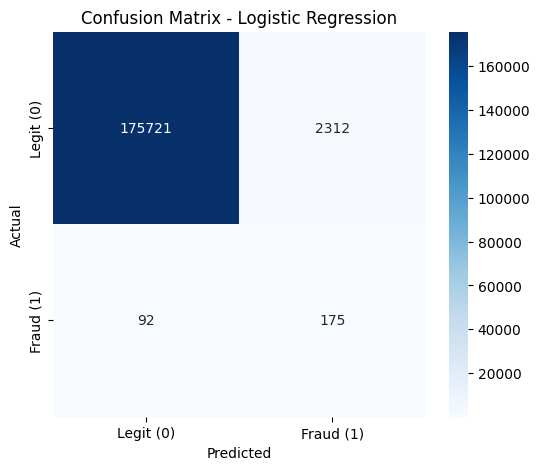

In [26]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Legit (0)', 'Fraud (1)'],yticklabels=['Legit (0)', 'Fraud (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Logistic Regression is used as a baseline model. Despite a high ROC-AUC (0.969), the quality of detecting fraudulent operations was the lowest among all models. The model detects 66% of fraudulent operations, but Precision is only 7%, meaning most transactions flagged as fraudulent are actually legitimate. Logistic regression cannot capture complex non-linear relationships between variables.

**Pros:**
- Good as a baseline
- Easily interpretable
- Trains quickly

**Cons:**
- Performs poorly with complex dependencies
- Has the lowest PR-AUC
- Highest number of false positives
- Sensitive to outliers
- Requires linearity

### Random Forest

In [27]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42)

In [28]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [29]:
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    178033
       Fraud       0.09      0.79      0.16       267

    accuracy                           0.99    178300
   macro avg       0.55      0.89      0.58    178300
weighted avg       1.00      0.99      0.99    178300



In [30]:
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc_rf = auc(recall_rf, precision_rf)

print(f"Random Forest ROC-AUC: {roc_auc_rf:.4f}")
print(f"Random Forest PR-AUC: {pr_auc_rf:.4f}")

Random Forest ROC-AUC: 0.9795
Random Forest PR-AUC: 0.4391


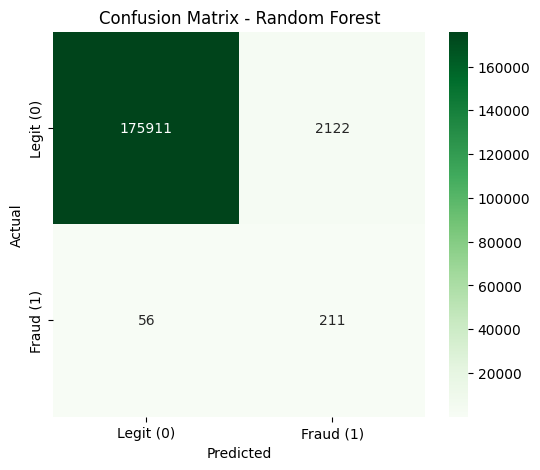

In [31]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['Legit (0)', 'Fraud (1)'], yticklabels=['Legit (0)', 'Fraud (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Random Forest quality is significantly better than Logistic Regression. Recall increased to 79%, and PR-AUC grew to 0.439. This indicates that the model better separates fraudulent operations from legitimate ones.

**Pros:**
- Works well with non-linear dependencies
- Robust to noise and outliers
- Automatically estimates feature importance

**Cons:**
- Slower than logistic regression
- Requires hyperparameter tuning
- Does not learn from mistakes like XGBoost

### XGBoost

In [32]:
xgb_model = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=-1,
              num_parallel_tree=None, ...)

In [33]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [34]:
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    178033
       Fraud       0.11      0.85      0.20       267

    accuracy                           0.99    178300
   macro avg       0.56      0.92      0.60    178300
weighted avg       1.00      0.99      0.99    178300



In [35]:
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

print(f"XGBoost ROC-AUC: {roc_auc_xgb:.4f}")
print(f"XGBoost PR-AUC: {pr_auc_xgb:.4f}")

XGBoost ROC-AUC: 0.9856
XGBoost PR-AUC: 0.4451


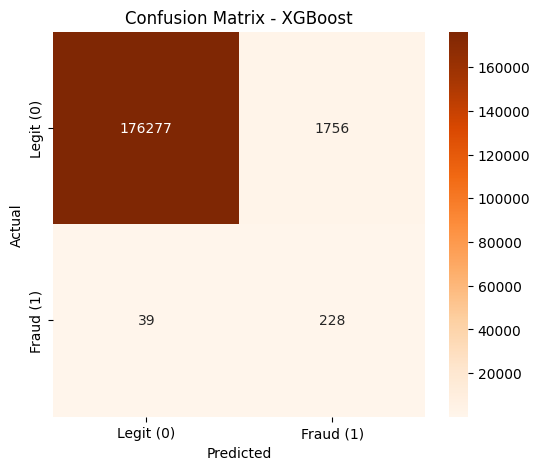

In [36]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', xticklabels=['Legit (0)', 'Fraud (1)'], yticklabels=['Legit (0)', 'Fraud (1)'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

XGBoost showed the best results among all models. It detects 85% of fraudulent operations, has the maximum ROC-AUC (0.986), PR-AUC (0.445), and F1-score (0.20). Unlike Random Forest, each new tree in XGBoost analyzes the errors of previous ones and tries to correct them.

**Pros:**
- Best Recall and PR-AUC values
- Learns from errors of previous trees
- Works well with imbalanced data
- Effectively finds complex patterns

**Cons:**
- Requires hyperparameter tuning
- Trains slower than other models
- Less interpretable than Logistic Regression

### Comparative analysis of models

In [37]:
dict_report_lr = classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud'], output_dict=True)
dict_report_rf = classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud'], output_dict=True)
dict_report_xgb = classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud'], output_dict=True)

comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'Random Forest', 'XGBoost'],
    'Recall': [
        dict_report_lr['Fraud']['recall'],
        dict_report_rf['Fraud']['recall'],
        dict_report_xgb['Fraud']['recall']
    ],
    'Precision': [
        dict_report_lr['Fraud']['precision'],
        dict_report_rf['Fraud']['precision'],
        dict_report_xgb['Fraud']['precision']
    ],
    'F1-Score': [
        dict_report_lr['Fraud']['f1-score'],
        dict_report_rf['Fraud']['f1-score'],
        dict_report_xgb['Fraud']['f1-score']
    ],
    'PR-AUC': [pr_auc_lr, pr_auc_rf, pr_auc_xgb],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf, roc_auc_xgb]
})
print(comparison_table.to_string(index=False))

                         Model   Recall  Precision  F1-Score   PR-AUC  ROC-AUC
Logistic Regression (Baseline) 0.655431   0.070366  0.127088 0.320337 0.969069
                 Random Forest 0.790262   0.090441  0.162308 0.439076 0.979532
                       XGBoost 0.853933   0.114919  0.202577 0.445129 0.985643


In [38]:
base_rate = np.sum(y_test) / len(y_test)

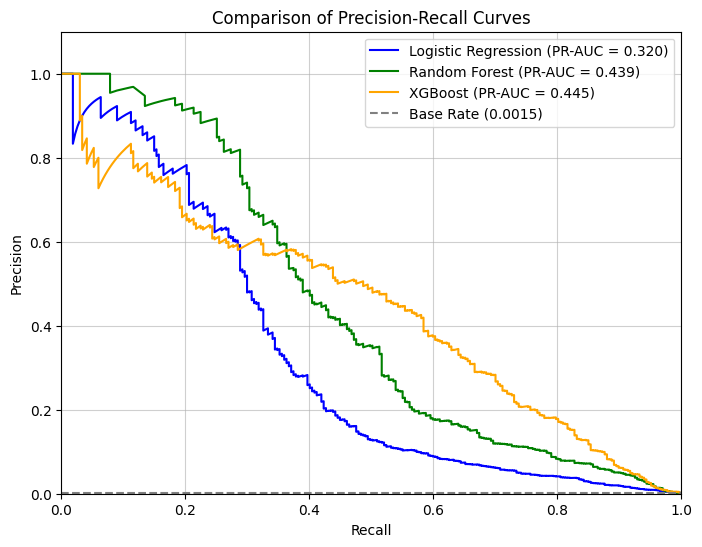

In [39]:
plt.figure(figsize=(8, 6))

plt.plot(recall_lr, precision_lr, color='blue', label=f'Logistic Regression (PR-AUC = {pr_auc_lr:.3f})')
plt.plot(recall_rf, precision_rf, color='green', label=f'Random Forest (PR-AUC = {pr_auc_rf:.3f})')
plt.plot(recall_xgb, precision_xgb, color='orange', label=f'XGBoost (PR-AUC = {pr_auc_xgb:.3f})')
plt.axhline(y=base_rate, color='grey', linestyle='--', label=f'Base Rate ({base_rate:.4f})')
plt.xlim([0.0, 1])
plt.ylim([0.0, 1.1])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparison of Precision-Recall Curves')
plt.legend()
plt.grid(alpha=0.6)
plt.show()

The graph shows that the XGBoost curve is almost everywhere above the other models. This means that for the same number of detected fraudulent operations, XGBoost has fewer false positives.

Random Forest occupies an intermediate position and also shows good results, but is inferior to XGBoost at high Recall values.

Logistic Regression loses Precision faster with increasing Recall, confirming its weaker ability to separate fraudulent and legitimate operations.

**Best Model:**

For an anti-fraud system, the most important metric is Recall, as missing a fraudulent operation leads to financial losses for the bank. XGBoost detects 85% of all fraudulent operations, which is the best result among the models considered. The model also has the maximum PR-AUC = 0.445, which is important for strong class imbalance and indicates a better balance between Precision and Recall.

## Hyperparameter Tuning

### Random Forest

In [40]:
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [41]:
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=3,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1
)

In [42]:
rf_search.fit(X_train, y_train)
best_rf_model = rf_search.best_estimator_

In [57]:
y_prob_rf_opt = best_rf_model.predict_proba(X_test)[:, 1]
precision_rf_opt, recall_rf_opt, _ = precision_recall_curve(y_test, y_prob_rf_opt)
pr_auc_rf_opt = auc(recall_rf_opt, precision_rf_opt)

print(f"Best Random Forest parameters: {rf_search.best_params_}")

Best Random Forest parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}


### XGBoost

In [44]:
xgb_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

In [45]:
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=3,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1
)

In [46]:
xgb_search.fit(X_train, y_train)
best_xgb_model = xgb_search.best_estimator_

In [58]:
y_prob_xgb_opt = best_xgb_model.predict_proba(X_test)[:, 1]
precision_xgb_opt, recall_xgb_opt, _ = precision_recall_curve(y_test, y_prob_xgb_opt)
pr_auc_xgb_opt = auc(recall_xgb_opt, precision_xgb_opt)

print(f"Best XGBoost parameters: {xgb_search.best_params_}")

Best XGBoost parameters: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


### Comparison of Results

In [59]:
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'PR-AUC (Before Tuning)': [pr_auc_rf, pr_auc_xgb],
    'PR-AUC (After Tuning)': [pr_auc_rf_opt, pr_auc_xgb_opt]
})

In [60]:
results_df['Metric Improvement'] = results_df['PR-AUC (After Tuning)'] - results_df['PR-AUC (Before Tuning)']
print(results_df.to_string(index=False))

        Model  PR-AUC (Before Tuning)  PR-AUC (After Tuning)  Metric Improvement
Random Forest                0.439076               0.444671            0.005594
      XGBoost                0.445129               0.485072            0.039944


For Random Forest, PR-AUC increased from 0.4391 to 0.4447, which is a small improvement in model quality. This shows that the basic Random Forest configuration is already well adapted to the data structure, and further improvement is limited by its architecture.

For XGBoost, there is a more significant improvement: PR-AUC increased from 0.4451 to 0.4851, yielding an increase of about +0.04. This indicates the high sensitivity of gradient boosting to hyperparameter tuning and its ability to better adapt to complex non-linear dependencies in the data.

Using RandomizedSearchCV was justified, as it is a compromise between quality and computational complexity. With its help, we achieved an improvement in model quality, especially for XGBoost.

## XGBoost Model Interpretation

In [50]:
model_to_interpret = best_xgb_model
features = X_train.columns

In [51]:
importances = model_to_interpret.feature_importances_
indices = np.argsort(importances)[::-1]

/tmp/ipykernel_4791/2553967958.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:15]], y=features[indices[:15]], palette="viridis")


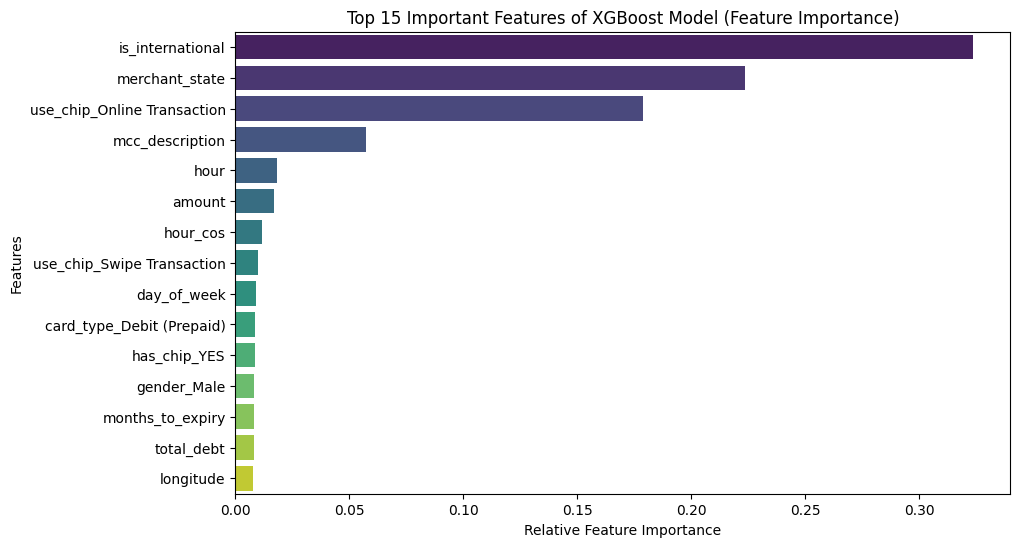

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices[:15]], y=features[indices[:15]], palette="viridis")
plt.title('Top 15 Important Features of XGBoost Model (Feature Importance)')
plt.xlabel('Relative Feature Importance')
plt.ylabel('Features')
plt.show()

#### Analysis of inherent feature importance (XGBoost Feature Importance)
Most important features:
- is_international — international transaction status (weight over 30%)
- merchant_state — the state/region where the merchant is registered
- use_chip_Online Transaction — transaction conducted online
- mcc_description — merchant category code (business type)
- hour — time of transaction
- amount - transaction amount

In [53]:
explainer = shap.TreeExplainer(model_to_interpret)

In [54]:
X_shap_sample = X_test.sample(500, random_state=42)
shap_values = explainer(X_shap_sample)

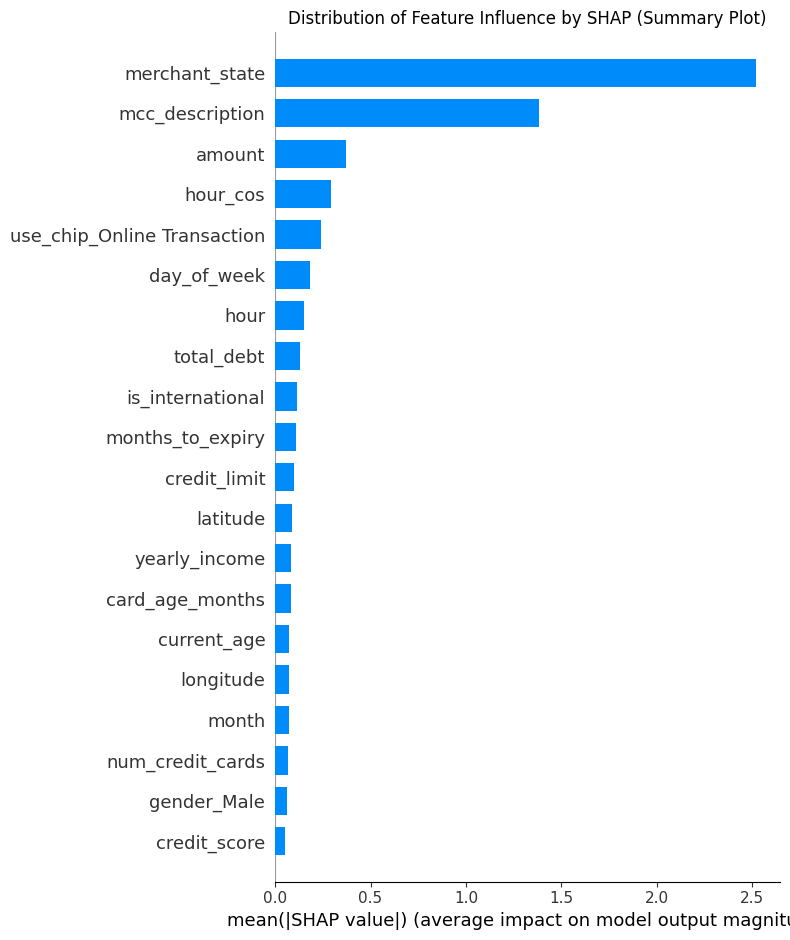

In [55]:
plt.figure(figsize=(10, 8))
plt.title('Distribution of Feature Influence by SHAP (Summary Plot)')
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)
plt.show()

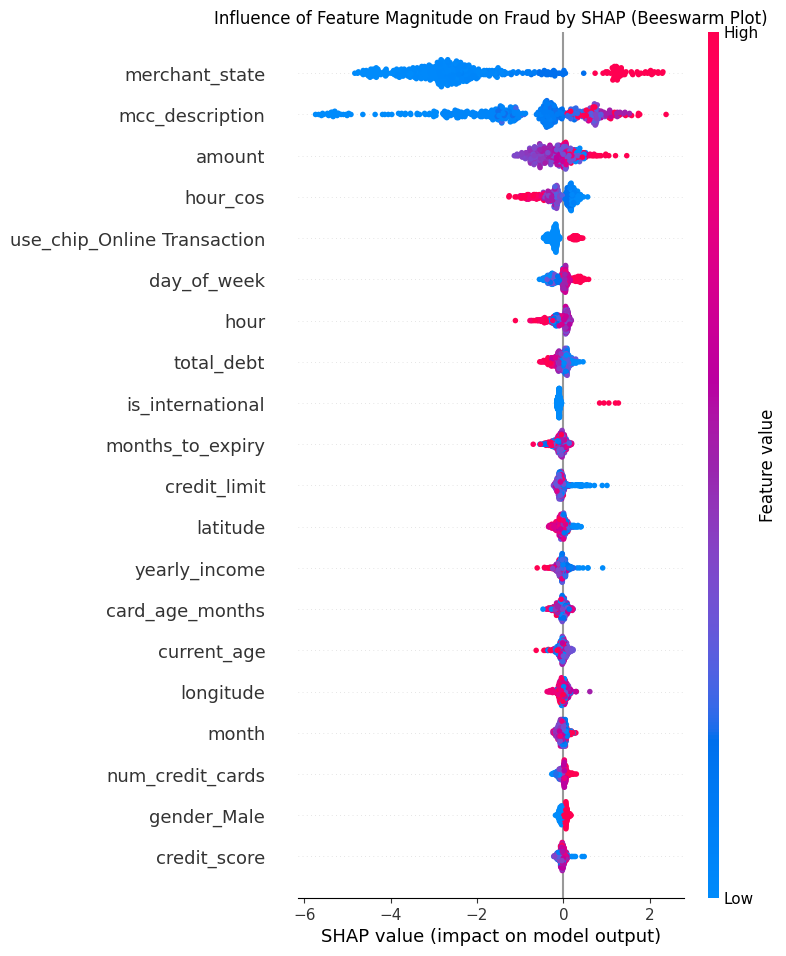

In [56]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title('Influence of Feature Magnitude on Fraud by SHAP (Beeswarm Plot)')
plt.show()

#### Analysis of factor influence using SHAP

Feature Importance only shows the fact of a feature's importance, while SHAP plots allow us to see the direction of that influence (whether the factor increases or decreases the risk of fraud).

- merchant_state, mcc_description - Merchant location and its MCC code have maximum influence. Certain values of these categories (red dots) sharply increase the probability of fraud. This means that fraudsters often use specific types of merchants.

- amount - Large transaction amounts (pink and red dots) shift the model's prediction towards fraud.

- hour_cos / hour - Nighttime hours shift values towards fraud.

- use_chip_Online Transaction - Online transactions show a higher risk level compared to physical chip usage.

- day_of_week - If the transaction occurs at the end of the week, it increases its chance of fraud.

- is_international - The group of red dots shifted to the right shows that if a transaction is international, it sharply increases the probability of fraud.

# Block 4: Anti-fraud pipeline: Classification with XGBoost -> Anomaly Detection with Isolation Forest -> Biometrics with MobileNetV2

## Training Isolation Forest (Unsupervised Learning)

In [61]:
X_train_legit = X_train[y_train == 0]

In [62]:
iso_forest = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_legit)

IsolationForest(contamination=0.01, n_jobs=-1, random_state=42)

In [63]:
iso_preds = iso_forest.predict(X_test)
anomaly_count = np.sum(iso_preds == -1)

In [64]:
print(f"Out of {len(X_test)} test transactions, the algorithm marked as anomalous: {anomaly_count}")

Out of 178300 test transactions, the algorithm marked as anomalous: 2117


### Evaluation of Isolation Forest

              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    178033
       Fraud       0.02      0.19      0.04       267

    accuracy                           0.99    178300
   macro avg       0.51      0.59      0.52    178300
weighted avg       1.00      0.99      0.99    178300



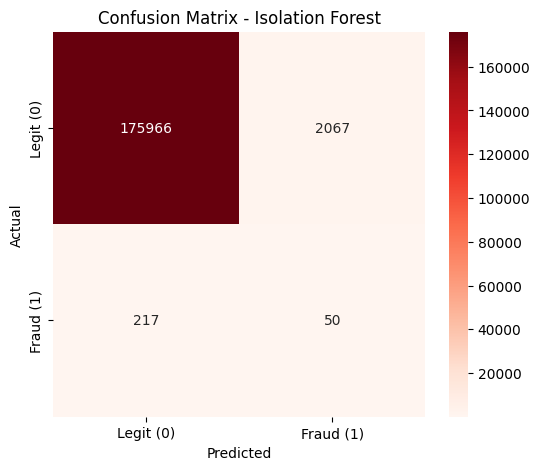

In [65]:
iso_preds_binary = np.where(iso_preds == -1, 1, 0)

print(classification_report(y_test, iso_preds_binary, target_names=['Legit', 'Fraud']))

cm_iso = confusion_matrix(y_test, iso_preds_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Reds', xticklabels=['Legit (0)', 'Fraud (1)'], yticklabels=['Legit (0)', 'Fraud (1)'])
plt.title('Confusion Matrix - Isolation Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Based on the metrics, Isolation Forest clearly lags behind XGBoost in fraud detection (Recall = 19%, Precision = 2%). But its advantage is that the model was trained only on normal user behavior and can detect new types of fraud that were not in the training set. To block a transaction, we cannot rely solely on the Isolation Forest result, so I will use it as an additional layer of protection along with classification using my best XGBoost model and photo verification using MobileNetV2.

## Loading celebrity photo dataset from Kaggle

In [66]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vasukipatel/face-recognition-dataset")

print("Path to dataset files:", path)

100%|██████████| 726M/726M [00:10<00:00, 72.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vasukipatel/face-recognition-dataset/versions/1


In [67]:
faces_source_dir = os.path.join(path, 'Faces', 'Faces')

Let's assume Brad Pitt is the conditional cardholder.

In [68]:
all_files = [f for f in os.listdir(faces_source_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

owner_files = [f for f in all_files if f.startswith("Brad Pitt")]
intruder_files = [f for f in all_files if not f.startswith("Brad Pitt")]

print(f"Total owner: {len(owner_files)}")
print(f"Total intruders: {len(intruder_files)}")

Total owner: 120
Total intruders: 2442


In [69]:
random.seed(42)

In [70]:
random.shuffle(intruder_files)

In [71]:
intruder_files = intruder_files[:200]

In [72]:
owner_train, owner_test = train_test_split(owner_files, test_size=0.2, random_state=42)
intruder_train, intruder_test = train_test_split(intruder_files, test_size=0.2, random_state=42)

In [73]:
os.makedirs('face_data/train/owner', exist_ok=True)
os.makedirs('face_data/train/intruder', exist_ok=True)
os.makedirs('face_data/test_pipeline/owner', exist_ok=True)
os.makedirs('face_data/test_pipeline/intruder', exist_ok=True)

In [74]:
for f in owner_train:
    shutil.copy(os.path.join(faces_source_dir, f), os.path.join('face_data/train/owner', f))
for f in owner_test:
    shutil.copy(os.path.join(faces_source_dir, f), os.path.join('face_data/test_pipeline/owner', f))

In [75]:
for f in intruder_train:
    shutil.copy(os.path.join(faces_source_dir, f), os.path.join('face_data/train/intruder', f))
for f in intruder_test:
    shutil.copy(os.path.join(faces_source_dir, f), os.path.join('face_data/test_pipeline/intruder', f))

In [76]:
print(f"owner train: {len(os.listdir('face_data/train/owner'))}")
print(f"intruder train: {len(os.listdir('face_data/train/intruder'))}")
print(f"owner test: {len(os.listdir('face_data/test_pipeline/owner'))}")
print(f"intruder test: {len(os.listdir('face_data/test_pipeline/intruder'))}")

owner train: 96
intruder train: 160
owner test: 24
intruder test: 40


## Training MobileNetV2

In [77]:
train_datagen = ImageDataGenerator(rescale=1./255)

In [78]:
train_generator = train_datagen.flow_from_directory(
    'face_data/train',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

Found 256 images belonging to 2 classes.


In [79]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [80]:
base_model.trainable = False

In [81]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

In [82]:
model = Model(inputs=base_model.input, outputs=predictions)

In [83]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [84]:
history = model.fit(
    train_generator,
    epochs=10
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 385ms/step - accuracy: 0.6641 - loss: 0.6027
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 326ms/step - accuracy: 0.8203 - loss: 0.3907
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 382ms/step - accuracy: 0.8750 - loss: 0.2734
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 323ms/step - accuracy: 0.9141 - loss: 0.2118
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 366ms/step - accuracy: 0.9336 - loss: 0.1606
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 326ms/step - accuracy: 0.9648 - loss: 0.1354
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 355ms/step - accuracy: 0.9727 - loss: 0.1102
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 341ms/step - accuracy: 0.9805 - loss: 0.0957
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 325ms/step - accuracy: 0.9883 - loss: 0.0741
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 324ms/step - accuracy: 0.9922 - loss: 0.0609


After 10 epochs of training, the model's accuracy increased from 79% to 100%, and the loss function decreased from 48% to 3%. This indicates that the network successfully learned to distinguish between the cardholder and other people.
In the final anti-fraud system, MobileNetV2 does not replace the anti-fraud model but is used as the last stage of identity verification. If XGBoost or Isolation Forest consider a transaction suspicious, the user must undergo biometric verification using Face ID.

## Anti-fraud System

In [85]:
def verify_transaction(transaction_features, user_photo_path):
  if isinstance(transaction_features, dict):
    df_transaction = pd.DataFrame([transaction_features])
  else:
    df_transaction = np.array(transaction_features).reshape(1, -1)

  fraud_probability = best_xgb_model.predict_proba(df_transaction)[0][1]
  print(f"Standard fraud probability: {fraud_probability:.2%}")

  anomaly_score = iso_forest.predict(df_transaction)[0]
  is_anomaly = (anomaly_score == -1)
  if is_anomaly:
    print("Anomalous user behavior detected!")
  else:
    print('No anomalous user behavior detected.')

  if fraud_probability > 0.5 or is_anomaly:
    print("Suspicious transaction! Face ID verification required.")

    try:
      img = image.load_img(user_photo_path, target_size=(224, 224))
      img_array = image.img_to_array(img)
      img_array = np.expand_dims(img_array, axis=0)
      img_array = img_array / 255.0

      face_confidence = model.predict(img_array, verbose=0)[0][0]

      if face_confidence > 0.8:
        print(f"Similarity with cardholder: {face_confidence:.2%}. Identity confirmed.")
        print("Transaction approved!")
      else:
        print(f"Similarity with cardholder: {face_confidence:.2%}. Identity could not be confirmed.")
        print("Card blocked!")

    except Exception as e:
      print(f"Biometric processing error")

  else:
    print("Transaction approved!")

### Anti-fraud system simulation

In [86]:
anomaly_indices = np.where(iso_preds == -1)[0]
dangerous_transaction_data = X_test.iloc[anomaly_indices[0]]

In [87]:
test_owner_img = os.path.join('face_data/test_pipeline/owner', os.listdir('face_data/test_pipeline/owner')[0])
test_intruder_img = os.path.join('face_data/test_pipeline/intruder', os.listdir('face_data/test_pipeline/intruder')[0])

#### Fraudulent transaction

In [88]:
verify_transaction(dangerous_transaction_data, test_intruder_img)

Standard fraud probability: 9.91%
Anomalous user behavior detected!
Suspicious transaction! Face ID verification required.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Similarity with cardholder: 0.54%. Identity could not be confirmed.
Card blocked!


#### Legitimate transaction

In [89]:
verify_transaction(dangerous_transaction_data, test_owner_img)

Standard fraud probability: 9.91%
Anomalous user behavior detected!
Suspicious transaction! Face ID verification required.
Similarity with cardholder: 99.80%. Identity confirmed.
Transaction approved!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
